<a href="https://colab.research.google.com/github/siwarTaha/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

Siwar Ehwass

## Project Overview

### Data Dictionary

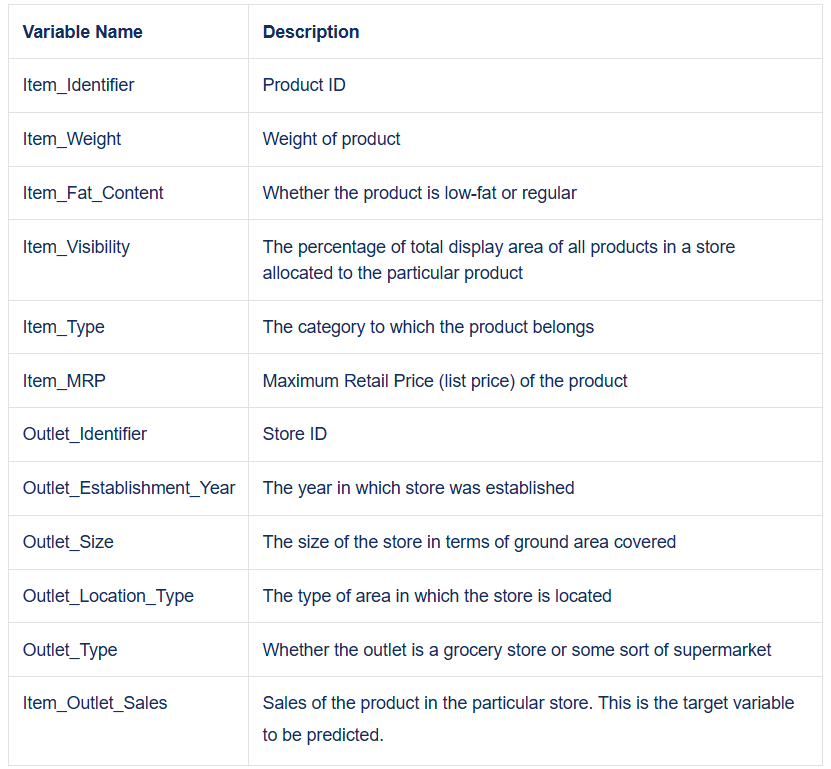

## Load and Inspect Data

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn import set_config
set_config(transform_output='pandas')

### Loading Data

In [2]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)
df_copy=df.copy()

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

### Drop ID's
- ID's dont help in the data analysis, so why keep?

In [5]:
df= df.drop(columns=['Item_Identifier','Outlet_Identifier'])

### Duplicated Rows

In [6]:
# check for duplicated data
duplicated_rows=df.duplicated()
duplicated_rows.sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [7]:
# number of unique values for each column
df.nunique()

,0
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3
Outlet_Type,4
Item_Outlet_Sales,3493


In [8]:
# percentage of unique values in each columns
df.nunique() / len(df) * 100

,0
Item_Weight,4.869178
Item_Fat_Content,0.058665
Item_Visibility,92.455708
Item_Type,0.187727
Item_MRP,69.670304
Outlet_Establishment_Year,0.105597
Outlet_Size,0.035199
Outlet_Location_Type,0.035199
Outlet_Type,0.046932
Item_Outlet_Sales,40.983222


### Missing Values
- Checking for NaN rows:

In [9]:
# see columns and rows where NaN is present
df.isna()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False


In [10]:
# check how many rows in each column has a missing value
null_sums=df.isna().sum()
null_sums

,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0
Outlet_Type,0
Item_Outlet_Sales,0


In [11]:
# check the percentage of null values
null_percent=null_sums/len(df)*100
null_percent[null_percent>0]

,0
Item_Weight,17.165317
Outlet_Size,28.276428


- 17.16% from Weight column has missing values
- 28.27% from Store size has missing value

#### Inspect Outlet Size

In [12]:
# filter categorical features
cat_cols=df_copy.select_dtypes('object').columns

# filter numerical features\
num_cols=df_copy.select_dtypes('number').columns

In [13]:
df_copy['Outlet_Size'].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2793
NaN,2410
Small,2388
High,932


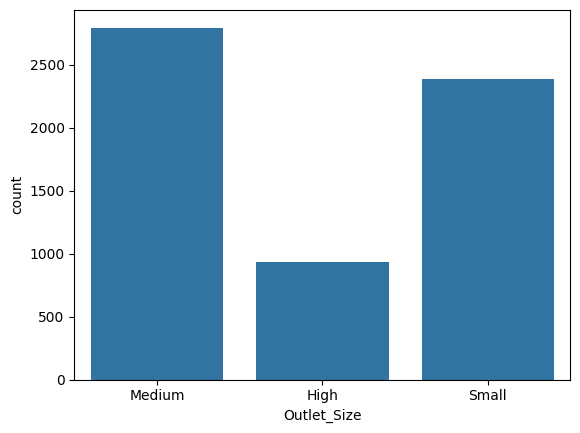

In [14]:
ax=sns.countplot(data=df, x='Outlet_Size')

- This graph shows that there are over 2000 Medium and Small Outlets Size while there are less than 1000 High Outlet size.

- Since Outlet_Size is a categorical feature with a large percentage of missing values (~28%):
  - dropping rows would result in significant data loss.
  - Filling with the most frequent category could introduce bias into the distribution.
  - Therefore, replacing missing values with "MISSING" is the most appropriate strategy because it preserves the data

In [15]:
# adress missing values in df (categorical/string) with placeholder MISSING
df_copy['Outlet_Size']=df_copy['Outlet_Size'].fillna('MISSING')

# check for applied changes
df_copy['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


#### Inspecting Item Weight

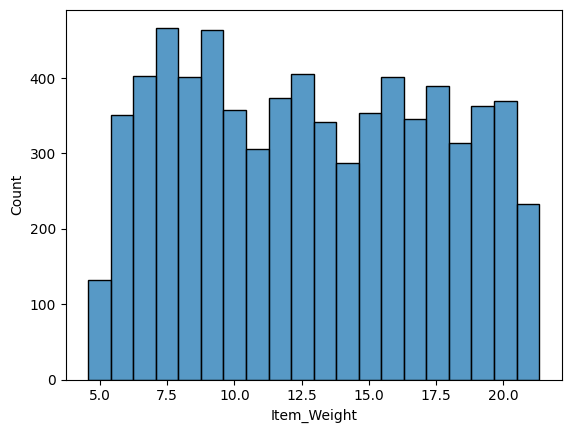

In [16]:
ax = sns.histplot(data=df,x='Item_Weight')

- Median is preferred because it is less affected by outliers and preserves the distribution better than using -1 or dropping rows.

- Since Item Weight is a numeric feature, missing values were filled using the median because it is less affected by outliers and helps preserve the overall distribution of the data.

In [17]:
df_copy['Item_Weight']=df_copy['Item_Weight'].fillna(df['Item_Weight'].median())
# check if they were filled
df_copy.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


Before filling number columns with placeholder, check describe()

In [18]:
cat_cols_df=df.select_dtypes('object').columns
num_cols_df=df.select_dtypes('number').columns

In [19]:
# summary of num cols
for col in num_cols_df:
  print(f'summary of {col}: ')
  print(df[col].describe())
  print("\n")

summary of Item_Weight: 
count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64


summary of Item_Visibility: 
count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64


summary of Item_MRP: 
count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64


summary of Outlet_Establishment_Year: 
count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64


summary of Item_Outlet_Sales: 
count     8523.000000
m

nothing needs to be addressed, so we fill all null values in num_cols with -1 placeholder:

### Consistent Values

Check each string column's value counts for inconsistent values:


In [20]:
# loop through each categorical/string column
for col in cat_cols_df:
  print(f'value counts of {col}: ')
  print(df[col].value_counts())
  print("\n")

value counts of Item_Fat_Content: 
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value counts of Item_Type: 
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


value counts of Outlet_Size: 
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64


value counts of Outlet_Location_Type: 
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64


value counts of Outlet_Type: 
Outlet_Type
Supe

This column has incosistent values:
- Fat Content: LF, reg, low fat

In [21]:
# check for inconsistent values
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [22]:
# Replace LF, low fat with Low Fat, and req with Regular:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF':'Low Fat',
                                             "low fat":'Low Fat',
                                             'reg':'Regular'})

# Confirm applied changes
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


### Describe Numeric Data
- min, max, mean

In [23]:
# get numeric columns
num_cols_df=df.select_dtypes('number').columns

# use the describe method and filter using .loc()
df[num_cols_df].describe().loc[['min','max','mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,4.555000,0.000000,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914


## Feature Inspection
- Exploratory Visuals & Analysis

In [24]:
# view data
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,NaN,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


### Histogram for Numeric Columns

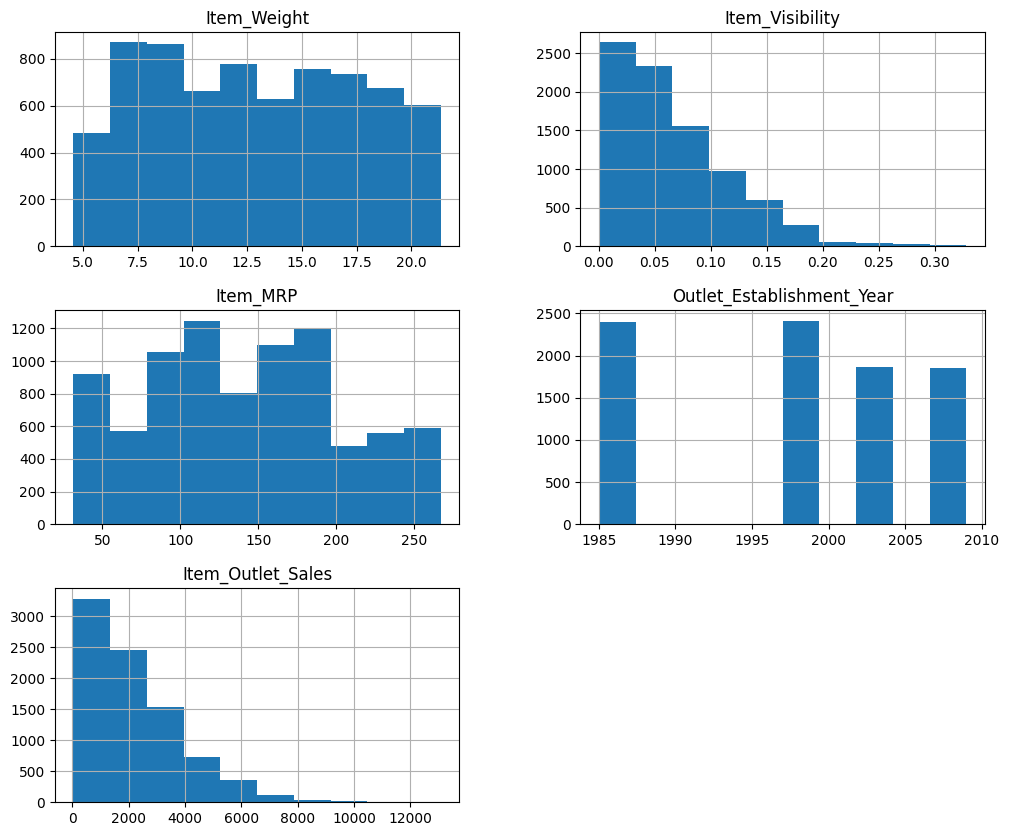

In [25]:
ax=df[num_cols].hist(figsize=(12,10));

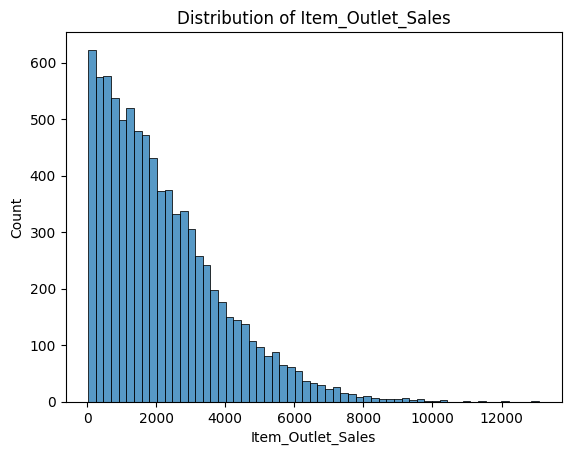

In [26]:
# item outlet sales
ax= sns.histplot(data=df,x='Item_Outlet_Sales')
ax.set_title("Distribution of Item_Outlet_Sales");

- Most items have low visibility.
- Most sales are low, with a few very high sales.
- Item weights are spread out, but many are around 11–13,
  - because we filled the null values with median earlier
- Retail prices vary a lot.
- Outlet establishment years occur at specific years only.

### Boxplot for numeric columns

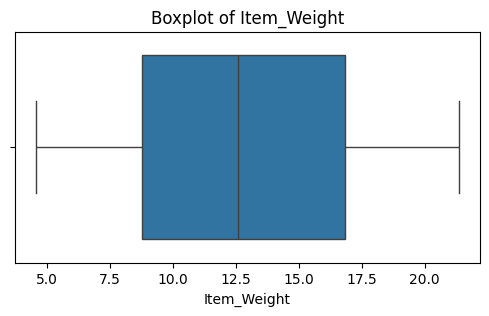

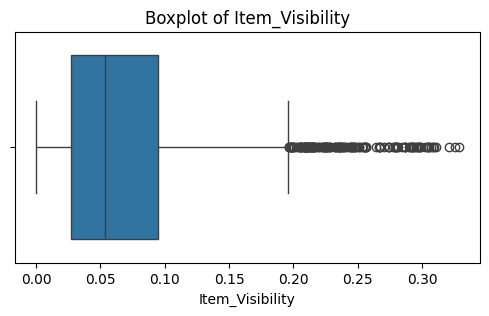

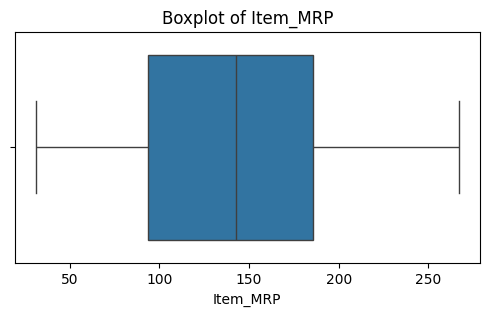

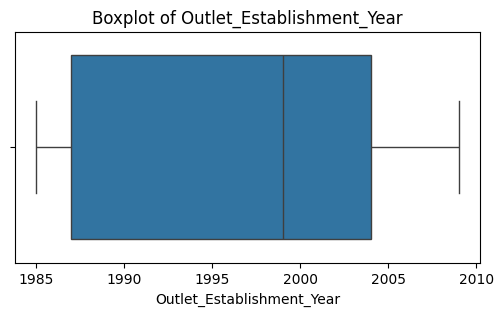

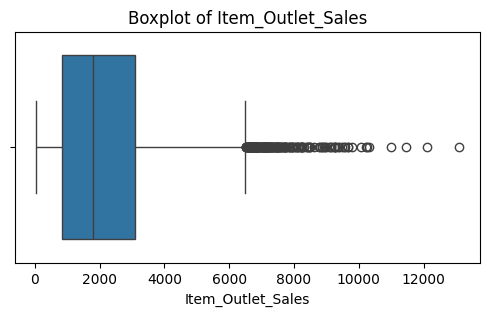

In [27]:
for col in num_cols_df:
    plt.figure(figsize=(6,3))
    ax = sns.boxplot(x=df[col])
    ax.set_title(f"Boxplot of {col}")

What we notice from the boxplots:

- Item_Visibility has many outliers (many unusually high values).
- Item_Outlet_Sales also has many high outliers.
- Item_Weight and Maximum Retail Price are more evenly spread.
- Bigger boxes mean more spread in the middle 50% of the data.

### Countplots for Categorical Columns

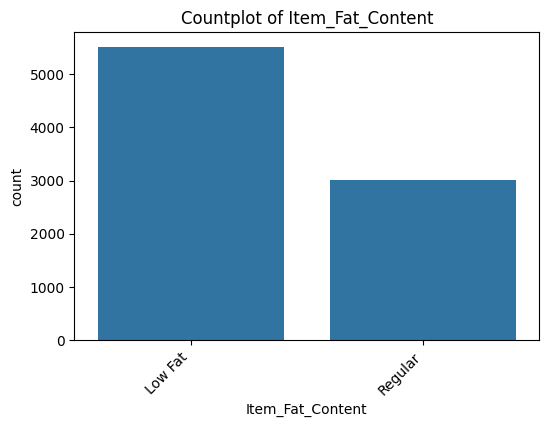

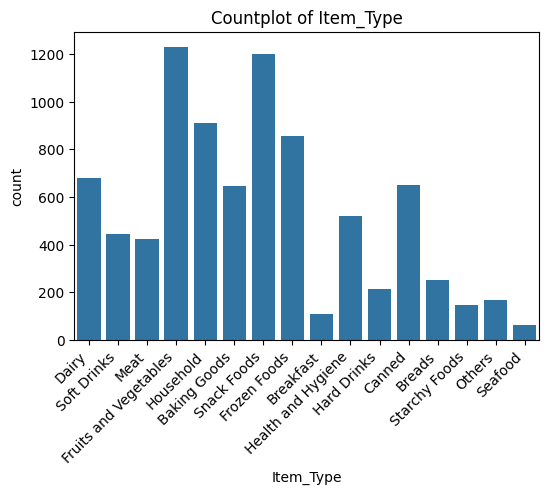

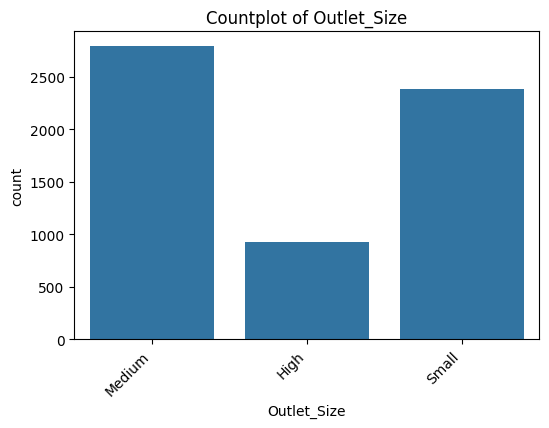

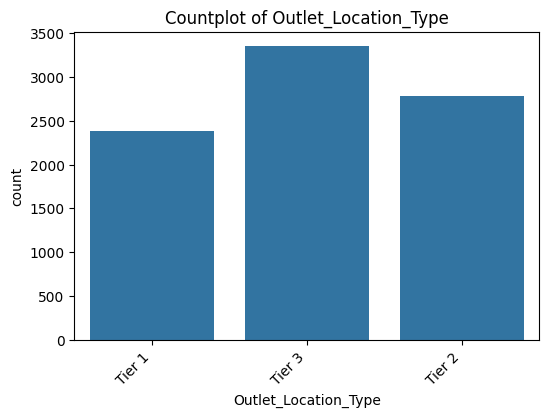

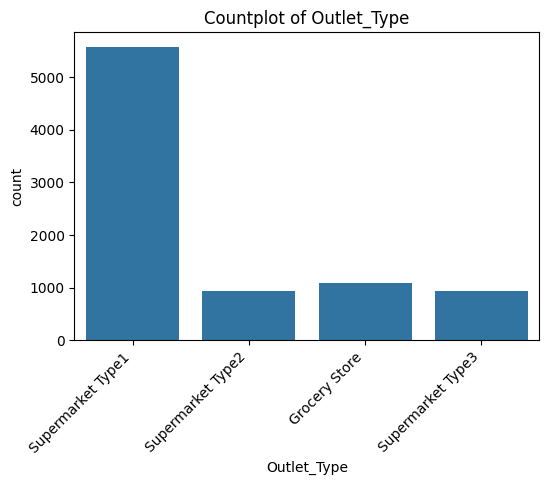

In [28]:
for col in cat_cols_df:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=df, x=col)
    ax.set_title(f"Countplot of {col}")
    plt.xticks(rotation=45, ha='right');

What we notice from the countplots:

- Low Fat items are more common than Regular items.
- Fruits and Vegetables and Snack Foods are the most common item types.
- Seafood and Breakfast items are the least common.
- Most outlets are Medium or Small in size.
- Tier 3 locations have the most outlets.
- Supermarket Type1 is much more common than the other outlet types.

### Correlation Heatmap


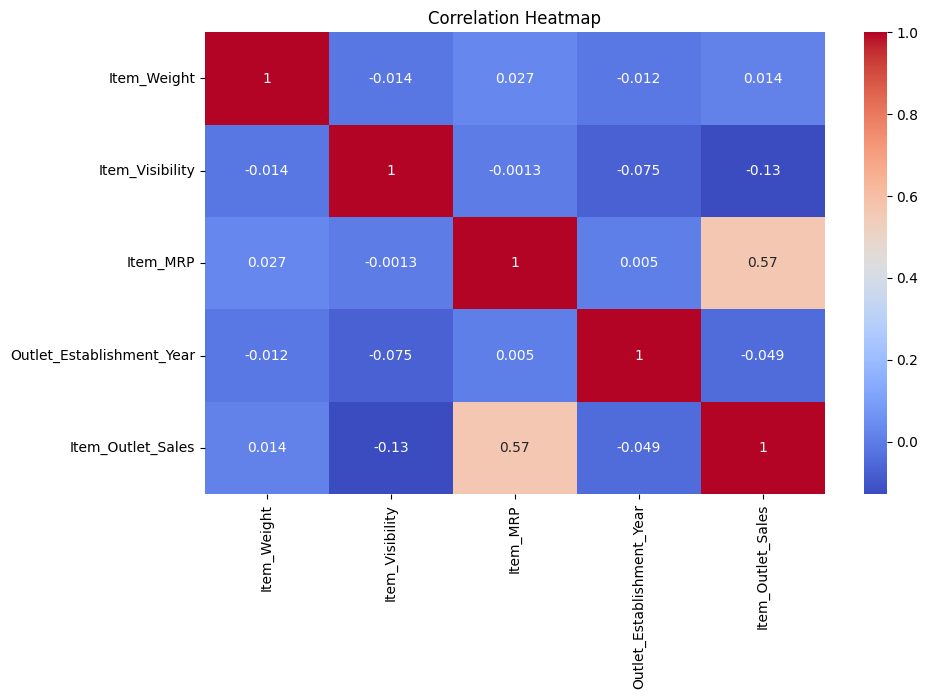

In [29]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

### Regression Plot: Maximum Retail Price & Item Outlet Sales

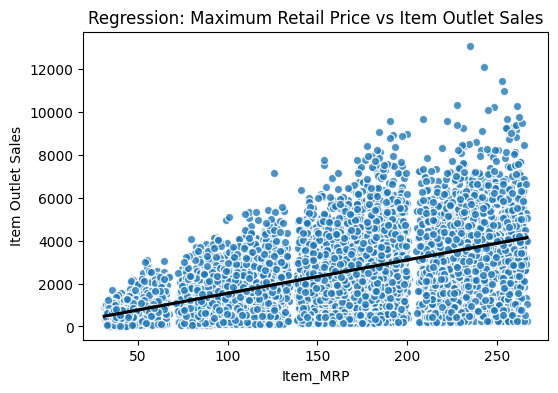

In [30]:
plt.figure(figsize=(6,4))
line_kws = dict(color='black')
scatter_kws = dict(edgecolor='white')
ax = sns.regplot(
    data=df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    line_kws=line_kws,
    scatter_kws=scatter_kws
)

ax.set(
    xlabel="Item_MRP",
    ylabel="Item Outlet Sales",
    title="Regression: Maximum Retail Price vs Item Outlet Sales"
);


- There is a positive relationship between Maximum Retail Price and Item Outlet Sales. As retail price increases, sales tend to increase as well.

### Countplot of Item Type

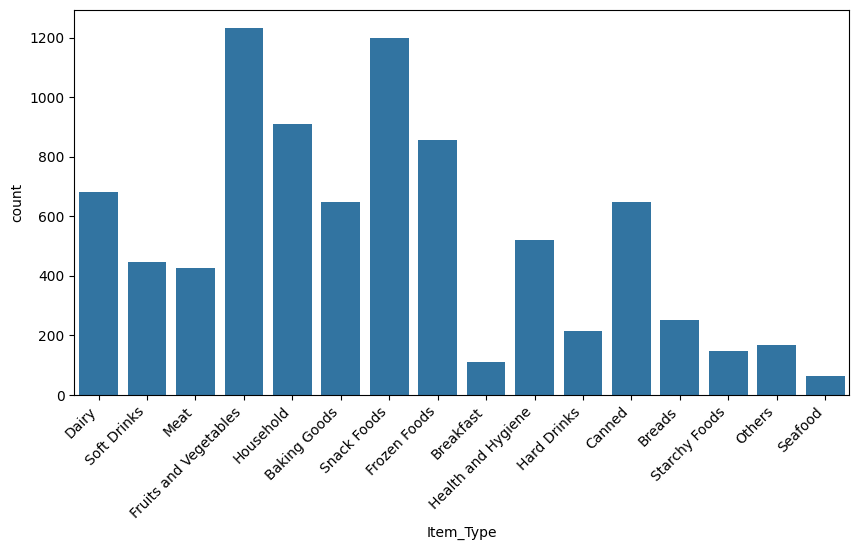

In [31]:
plt.figure(figsize=(10,5))

ax = sns.countplot(data=df, x='Item_Type')

ax.set_title="Countplot of Item Types";

plt.xticks(rotation=45, ha='right');

- Fruits and Vegetables and Snack Foods are the most common item categories, while Seafood and Breakfast items appear least frequently.

## Model Validation

In [32]:
# inspect data
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,NaN,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


In [33]:
# view strings and categorical data
cat_cols_df=df.select_dtypes('object').columns
df[cat_cols_df]

,Item_Fat_Content,Item_Type,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,Low Fat,Dairy,Medium,Tier 1,Supermarket Type1
1,Regular,Soft Drinks,Medium,Tier 3,Supermarket Type2
2,Low Fat,Meat,Medium,Tier 1,Supermarket Type1
3,Regular,Fruits and Vegetables,NaN,Tier 3,Grocery Store
4,Low Fat,Household,High,Tier 3,Supermarket Type1
...,...,...,...,...,...
8518,Low Fat,Snack Foods,High,Tier 3,Supermarket Type1
8519,Regular,Baking Goods,NaN,Tier 2,Supermarket Type1
8520,Low Fat,Health and Hygiene,Small,Tier 2,Supermarket Type1
8521,Regular,Snack Foods,Medium,Tier 3,Supermarket Type2


- Ordinal: Outet size only
- Nominal:  Everything Else
- Numeric: The rest of the df

### Train test split

In [35]:
# target column
y= df['Item_Outlet_Sales']
X= df.drop(columns='Item_Outlet_Sales')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Ordinal Pipleline

In [36]:
# see value counts for possible ordinal features
ord_cols=['Outlet_Size']
X_train[ord_cols].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


In [45]:
# order cats
size_order=['MISSING','Small','Medium','High']
# Pipeline
ord_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OrdinalEncoder(categories=[size_order]),
  StandardScaler()
)
ord_tuple = ('Ordinal', ord_pipe, ord_cols)

ord_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='MISSING', strategy='constant')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['MISSING', 'Small', 'Medium',
                                             'High']])),
                ('standardscaler', StandardScaler())])

### Nominal

In [42]:
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns
ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='NA'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

ohe_tuple = ('Categorical', ohe_pipe, ohe_cols)
ohe_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='NA', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

### Numeric

In [43]:
num_cols_train = X_train.select_dtypes("number").columns
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
num_tuple = ('Numeric', num_pipe, num_cols_train)

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### Column Transformers

In [46]:
col_transformer = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)
# Fit on training data
col_transformer.fit(X_train)


ColumnTransformer(transformers=[('Numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                ('Ordinal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='MISSING',
                                                                strategy='constant')),
                                                 ('ord...
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Outlet_Size']),
                                ('Categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Location_Type', 'Outlet_Type'], dtype='object'))],
                  verbose_feature_names_out=False)

In [47]:
# Transform TRAIN
X_train_processed = col_transformer.transform(X_train)
X_train_processed.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
4776,0.827485,-0.712775,1.828109,1.327849,0.748125,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7510,0.566644,-1.291052,0.603369,1.327849,0.748125,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5828,-0.121028,1.813319,0.244541,0.136187,0.748125,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5327,-1.158464,-1.004931,-0.952591,0.732018,-0.264370,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4810,1.538870,-0.965484,-0.336460,0.493686,-1.276865,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [48]:
# Transform TEST
X_test_processed = col_transformer.transform(X_test)
X_test_processed.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
7503,0.341372,-0.776646,-0.998816,-1.293807,1.760619,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2957,-1.169135,0.100317,-1.585194,-0.102145,-0.264370,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7031,0.388798,-0.482994,-1.595784,0.136187,0.748125,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1084,-0.049889,-0.415440,0.506592,-1.532139,0.748125,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
856,-0.632039,-1.047426,0.886725,0.732018,-0.264370,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
